<a href="https://colab.research.google.com/github/maxgov2703/product-metrics-dashboard/blob/main/notebooks/product_metrics_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# создаем синтетический датасет активности пользователей
np.random.seed(42)

dates = pd.date_range(start="2024-01-01", end="2024-03-31")
user_ids = np.random.randint(1, 5000, size=20000)

df = pd.DataFrame({
    "event_date": np.random.choice(dates, size=20000),
    "user_id": user_ids
})

df = df.sort_values("event_date")

df.head()

,event_date,user_id
13689,2024-01-01,168
4637,2024-01-01,530
17429,2024-01-01,155
19941,2024-01-01,3337
8578,2024-01-01,2701


In [2]:
df.shape

(20000, 2)

In [3]:
df.to_csv("user_activity.csv", index=False)

In [4]:
# считаем DAU
dau = df.groupby("event_date")["user_id"].nunique().reset_index()

dau = dau.rename(columns={"user_id": "DAU"})

dau.head()

,event_date,DAU
0,2024-01-01,197
1,2024-01-02,204
2,2024-01-03,220
3,2024-01-04,218
4,2024-01-05,240


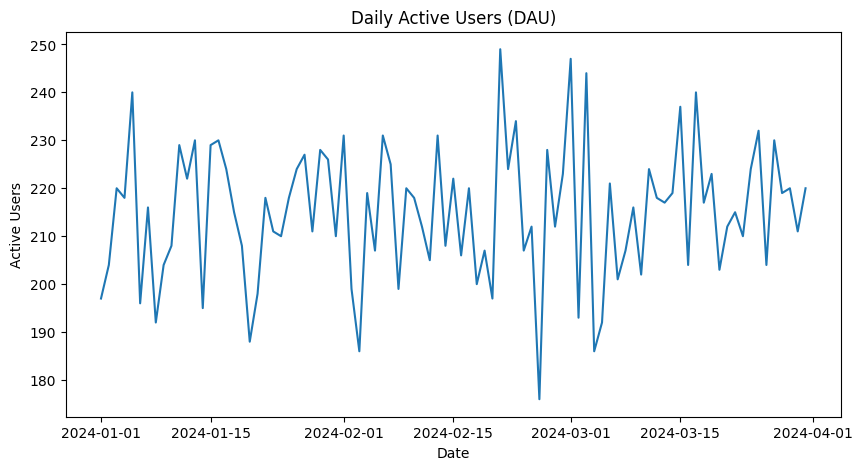

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(dau["event_date"], dau["DAU"])

plt.title("Daily Active Users (DAU)")
plt.xlabel("Date")
plt.ylabel("Active Users")

plt.savefig("plots/dau_trend.png")

plt.show()

In [7]:
# переводим дату в формат недели
df["week"] = df["event_date"].dt.to_period("W")

# считаем WAU
wau = df.groupby("week")["user_id"].nunique().reset_index()

wau = wau.rename(columns={"user_id": "WAU"})

wau.head()

,week,WAU
0,2024-01-01/2024-01-07,1316
1,2024-01-08/2024-01-14,1285
2,2024-01-15/2024-01-21,1322
3,2024-01-22/2024-01-28,1346
4,2024-01-29/2024-02-04,1343


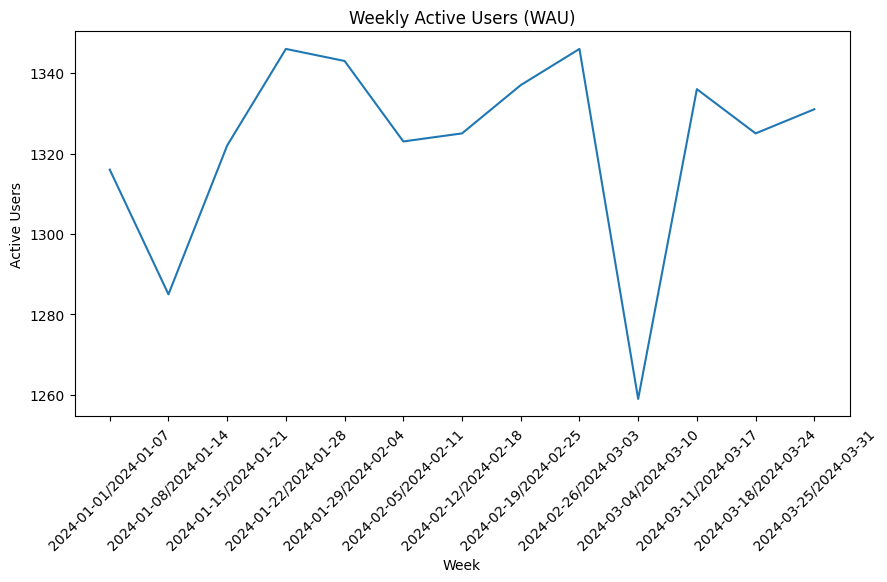

In [8]:
plt.figure(figsize=(10,5))

plt.plot(wau["week"].astype(str), wau["WAU"])

plt.title("Weekly Active Users (WAU)")
plt.xlabel("Week")
plt.ylabel("Active Users")

plt.xticks(rotation=45)

plt.savefig("plots/wau_trend.png")

plt.show()

In [9]:
# переводим дату в формат месяца
df["month"] = df["event_date"].dt.to_period("M")

# считаем MAU
mau = df.groupby("month")["user_id"].nunique().reset_index()

mau = mau.rename(columns={"user_id": "MAU"})

mau

,month,MAU
0,2024-01,3745
1,2024-02,3629
2,2024-03,3730


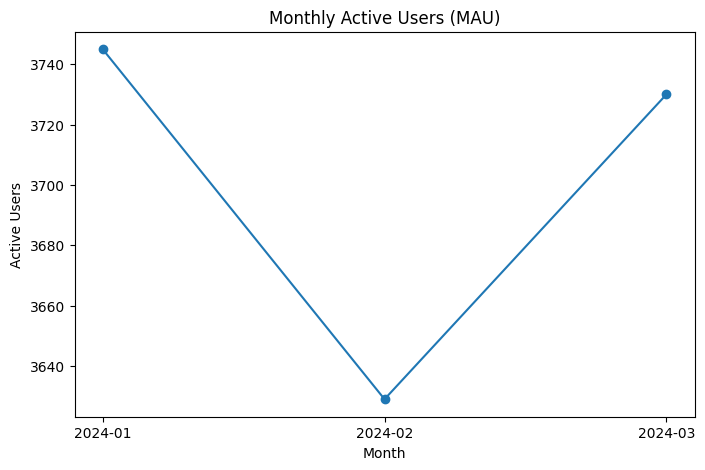

In [10]:
plt.figure(figsize=(8,5))

plt.plot(mau["month"].astype(str), mau["MAU"], marker="o")

plt.title("Monthly Active Users (MAU)")
plt.xlabel("Month")
plt.ylabel("Active Users")

plt.savefig("plots/mau_trend.png")

plt.show()

In [11]:
# средний DAU
avg_dau = dau["DAU"].mean()

# средний MAU
avg_mau = mau["MAU"].mean()

# считаем stickiness
stickiness = avg_dau / avg_mau

stickiness

np.float64(0.05807826899325458)

Показатель stickiness (привлекательности продукта)

Показатель stickiness (привлекательности продукта) (DAU/MAU) измеряет, как часто пользователи возвращаются к продукту.

Более высокие значения указывают на более высокую вовлеченность пользователей.

In [12]:
# дата первого визита пользователя
first_visit = df.groupby("user_id")["event_date"].min().reset_index()

first_visit = first_visit.rename(columns={"event_date": "first_visit_date"})

first_visit.head()

,user_id,first_visit_date
0,1,2024-01-21
1,2,2024-01-31
2,3,2024-01-15
3,4,2024-01-11
4,5,2024-01-15


In [13]:
df_retention = df.merge(first_visit, on="user_id")

df_retention.head()

,event_date,user_id,week,month,first_visit_date
0,2024-01-01,168,2024-01-01/2024-01-07,2024-01,2024-01-01
1,2024-01-01,530,2024-01-01/2024-01-07,2024-01,2024-01-01
2,2024-01-01,155,2024-01-01/2024-01-07,2024-01,2024-01-01
3,2024-01-01,3337,2024-01-01/2024-01-07,2024-01,2024-01-01
4,2024-01-01,2701,2024-01-01/2024-01-07,2024-01,2024-01-01


In [14]:
# считаем разницу между текущим событием и первым визитом
df_retention["days_since_first_visit"] = (
    df_retention["event_date"] - df_retention["first_visit_date"]
).dt.days

df_retention.head()

,event_date,user_id,week,month,first_visit_date,days_since_first_visit
0,2024-01-01,168,2024-01-01/2024-01-07,2024-01,2024-01-01,0
1,2024-01-01,530,2024-01-01/2024-01-07,2024-01,2024-01-01,0
2,2024-01-01,155,2024-01-01/2024-01-07,2024-01,2024-01-01,0
3,2024-01-01,3337,2024-01-01/2024-01-07,2024-01,2024-01-01,0
4,2024-01-01,2701,2024-01-01/2024-01-07,2024-01,2024-01-01,0


In [15]:
# считаем количество пользователей по дням
retention = (
    df_retention.groupby("days_since_first_visit")["user_id"]
    .nunique()
    .reset_index()
)

# общее число пользователей
total_users = retention.loc[retention["days_since_first_visit"] == 0, "user_id"].values[0]

# считаем retention
retention["retention_rate"] = retention["user_id"] / total_users

retention.head(10)

,days_since_first_visit,user_id,retention_rate
0,0,4906,1.000000
1,1,218,0.044435
2,2,221,0.045047
3,3,208,0.042397
4,4,203,0.041378
5,5,199,0.040563
6,6,227,0.046270
7,7,213,0.043416
8,8,200,0.040766
9,9,213,0.043416


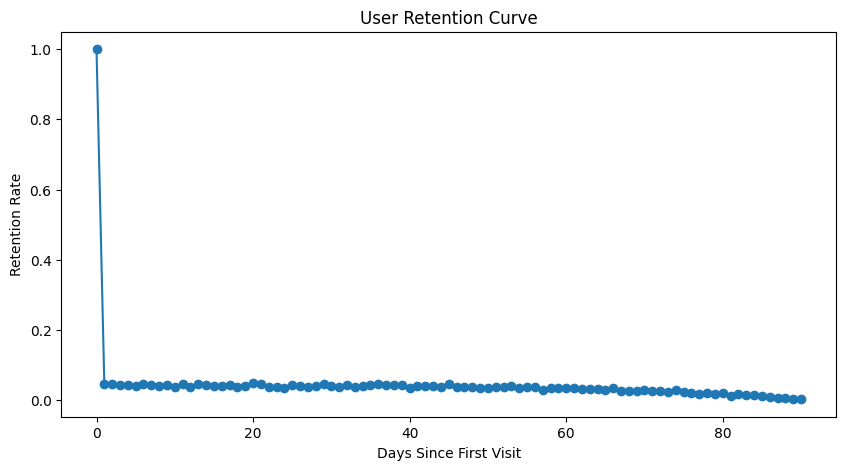

In [16]:
plt.figure(figsize=(10,5))

plt.plot(retention["days_since_first_visit"], retention["retention_rate"], marker="o")

plt.title("User Retention Curve")
plt.xlabel("Days Since First Visit")
plt.ylabel("Retention Rate")

plt.savefig("plots/retention_curve.png")

plt.show()

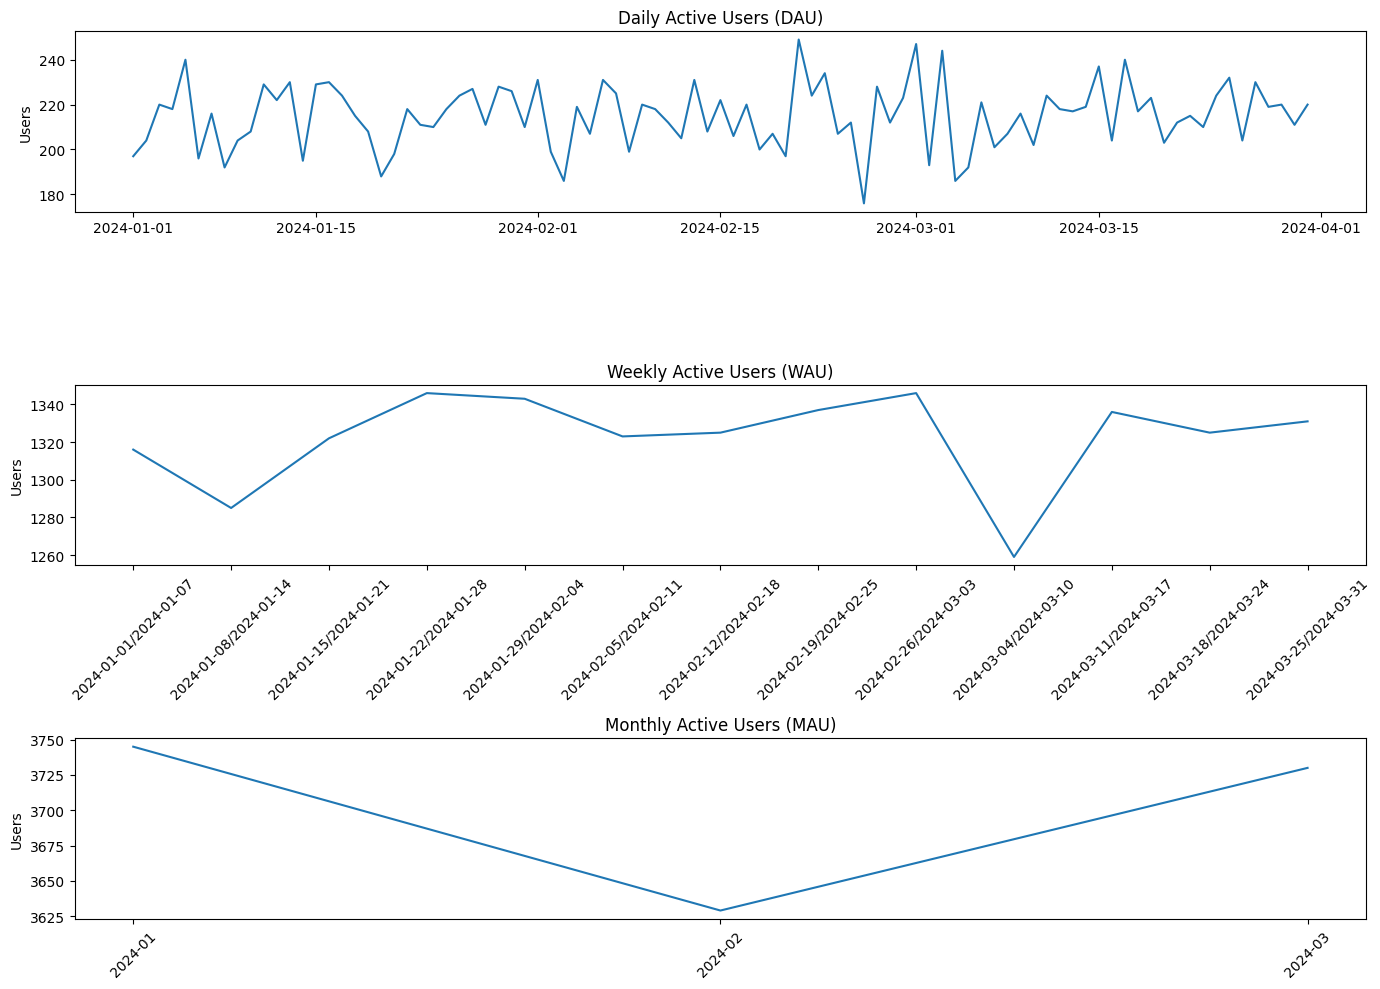

In [18]:
plt.figure(figsize=(14,10))

# график DAU
plt.subplot(3,1,1)
plt.plot(dau["event_date"], dau["DAU"])
plt.title("Daily Active Users (DAU)")
plt.ylabel("Users")

# график WAU
plt.subplot(3,1,2)
plt.plot(wau["week"].astype(str), wau["WAU"])
plt.title("Weekly Active Users (WAU)")
plt.ylabel("Users")
plt.xticks(rotation=45)

# график MAU
plt.subplot(3,1,3)
plt.plot(mau["month"].astype(str), mau["MAU"])
plt.title("Monthly Active Users (MAU)")
plt.ylabel("Users")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("plots/product_metrics_dashboard.png")

plt.show()